# 7CS353 Machine Learning Lab &mdash; Assignment 4
### Univariate and Multivariate Outlier Detection

**Name:** Atharv V Kulkarni
**PRN:** 245109074
**Class:** TY B.Tech CSE (B)

## Section 0: Dataset Generation

**Setup:** generate the fixed-seed student performance dataset and save it to student_performance.csv

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

rng=np.random.default_rng(seed=353)
n=150

study=rng.normal(6,1.5,n).clip(2,11).round(1)
score=np.clip(8*study+rng.normal(0,10,n),10,100).round(1)

extras=pd.DataFrame({"study_hours":[12.0,2.5,9.0],"exam_score":[94.0,88.0,18.0]})
df=pd.concat([pd.DataFrame({"study_hours":study,"exam_score":score}),extras],ignore_index=True)
df.to_csv("student_performance.csv",index=False)
df.describe().round(2)

,study_hours,exam_score
count,153.00,153.00
mean,5.99,48.07
std,1.62,16.74
min,2.50,13.90
25%,4.90,36.00
50%,5.80,47.20
75%,7.00,58.80
max,12.00,94.00


## B.1 Load and Explore

**B1:** load student_performance.csv fresh and print describe()

In [15]:
df=pd.read_csv("student_performance.csv")
df.describe().round(2)

,study_hours,exam_score
count,153.00,153.00
mean,5.99,48.07
std,1.62,16.74
min,2.50,13.90
25%,4.90,36.00
50%,5.80,47.20
75%,7.00,58.80
max,12.00,94.00


**Answer:** study_hours has mean 5.99 and median 5.80 (mean above median by 0.19). exam_score has mean 48.07 and median 47.20 (mean above median by 0.87). exam_score shows the larger gap.

**B2:** scatter plot of study_hours vs exam_score

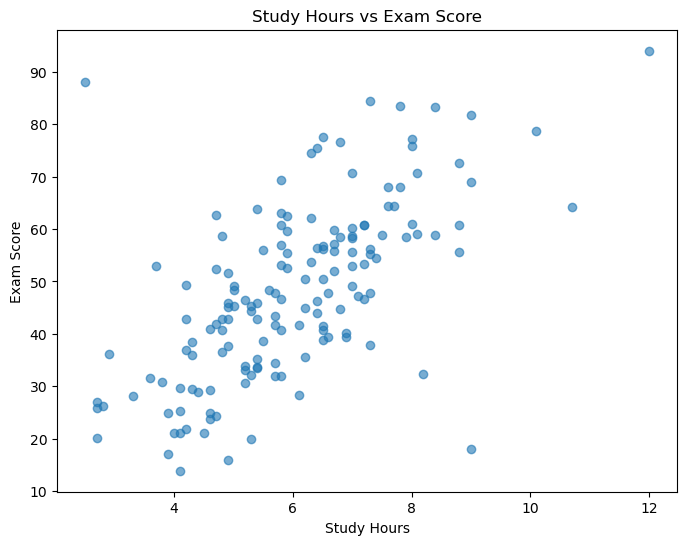

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(df["study_hours"],df["exam_score"],alpha=0.6)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

**Answer:** there is a clear positive, roughly linear trend - more study hours generally goes with a higher exam score. three points look suspicious by eye: one far right with unusually high study hours, one with ordinary study hours but a surprisingly high score, and one with high study hours but a surprisingly low score that breaks the trend line.

## B.2 Univariate Outlier Detection

**B3:** IQR fence bounds for both columns, flagged rows, and side-by-side box plots

study_hours fence: 1.7500000000000009 10.149999999999999
exam_score fence: 1.8000000000000043 93.0
     study_hours  exam_score
87          10.7        64.2
150         12.0        94.0
     study_hours  exam_score
150         12.0        94.0


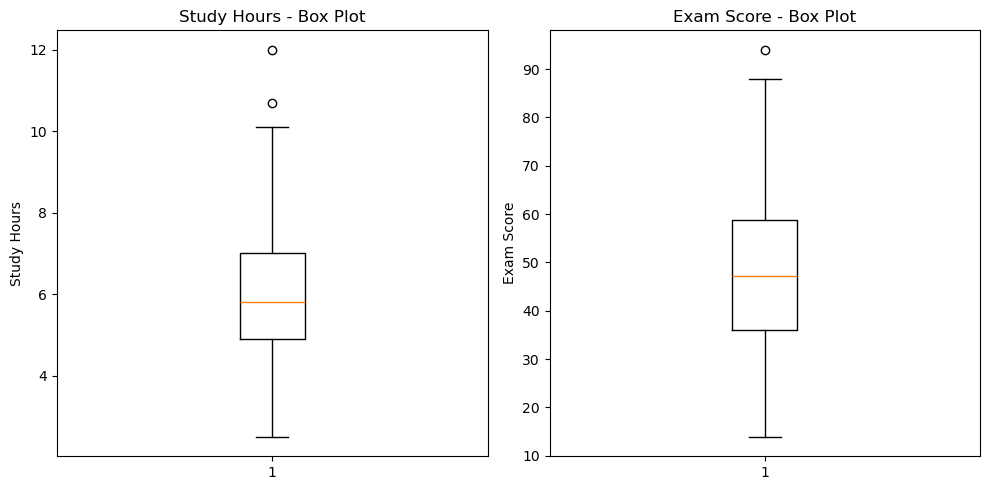

In [17]:
def iqr_bounds(s):
    Q1=s.quantile(0.25)
    Q3=s.quantile(0.75)
    IQR=Q3-Q1
    return Q1-1.5*IQR,Q3+1.5*IQR

study_low,study_high=iqr_bounds(df["study_hours"])
score_low,score_high=iqr_bounds(df["exam_score"])
print("study_hours fence:",study_low,study_high)
print("exam_score fence:",score_low,score_high)

flagged_study=df[(df["study_hours"]<study_low)|(df["study_hours"]>study_high)]
flagged_score=df[(df["exam_score"]<score_low)|(df["exam_score"]>score_high)]
print(flagged_study)
print(flagged_score)

fig,ax=plt.subplots(1,2,figsize=(10,5))
ax[0].boxplot(df["study_hours"])
ax[0].set_title("Study Hours - Box Plot")
ax[0].set_ylabel("Study Hours")
ax[1].boxplot(df["exam_score"])
ax[1].set_title("Exam Score - Box Plot")
ax[1].set_ylabel("Exam Score")
plt.tight_layout()
plt.show()

**B4:** fill in the observation table

**Answer:**

| Index | study_hours flagged? | exam_score flagged? | Interpretation |
|---|---|---|---|
| 150 | Yes | Yes | flagged univariately in both columns |
| 151 | No | No | not caught univariately |
| 152 | No | No | not caught univariately |

## B.3 Euclidean Distance from Centroid

**B5:** z-score both columns, compute Euclidean distance from centroid, apply all three thresholding strategies

In [18]:
cols=df[["study_hours","exam_score"]]
Xz=(cols-cols.mean())/cols.std()
euclid=np.sqrt((Xz**2).sum(axis=1))

top10_idx=np.argsort(euclid.values)[-10:]
print("top-10 flagged indices:",sorted(top10_idx.tolist()))

scalar_idx=df.index[euclid>3.0]
print("scalar threshold flagged indices:",scalar_idx.tolist())

Q1_e,Q3_e=np.percentile(euclid,[25,75])
iqr_thresh_e=Q3_e+1.5*(Q3_e-Q1_e)
iqr_idx_e=df.index[euclid>iqr_thresh_e]
print("iqr based flagged indices:",iqr_idx_e.tolist())

top-10 flagged indices: [2, 28, 41, 87, 88, 116, 123, 150, 151, 152]
scalar threshold flagged indices: [2, 87, 150, 151]
iqr based flagged indices: [150, 151]


**Answer:** no, not consistently. all three are only caught together by the fixed top-10 rule. the scalar threshold (z>3.0) catches 150 and 151 but misses 152. the iqr-based threshold also only catches 150 and 151, missing 152 as well.

**B6:** scatter plot of the original data, coloured by IQR-based Euclidean flag, with univariate IQR boundaries overlaid

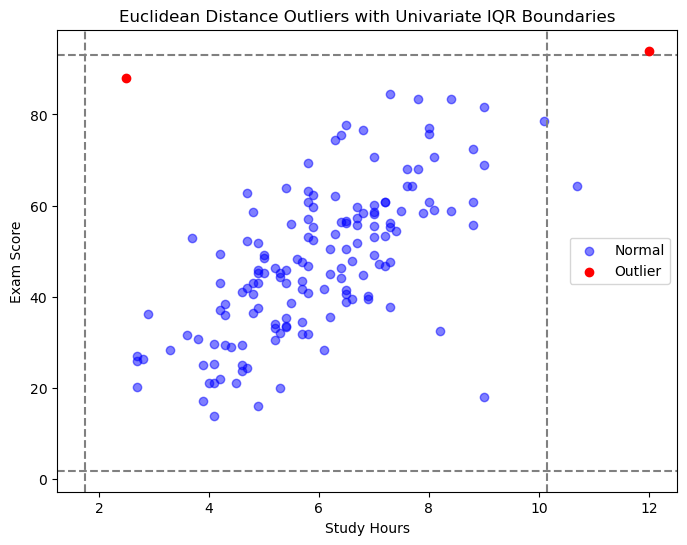

In [19]:
mask_e=euclid>iqr_thresh_e
plt.figure(figsize=(8,6))
plt.scatter(df.loc[~mask_e,"study_hours"],df.loc[~mask_e,"exam_score"],alpha=0.5,color="blue",label="Normal")
plt.scatter(df.loc[mask_e,"study_hours"],df.loc[mask_e,"exam_score"],color="red",zorder=5,label="Outlier")
plt.axhline(score_low,linestyle="--",color="gray")
plt.axhline(score_high,linestyle="--",color="gray")
plt.axvline(study_low,linestyle="--",color="gray")
plt.axvline(study_high,linestyle="--",color="gray")
plt.title("Euclidean Distance Outliers with Univariate IQR Boundaries")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.legend()
plt.show()

**Answer:** not the same points. univariate iqr (b.2/b.3) flags rows 87 and 150. euclidean iqr-based (b.6) flags rows 150 and 151. row 87 is caught only by the univariate check, row 151 is caught only by the euclidean check, and row 152 is missed by both.

## B.4 Mahalanobis Distance

**B7:** 2x2 covariance matrix, Mahalanobis distances for all rows, top-5 comparison with Euclidean

In [20]:
X=df[["study_hours","exam_score"]].values
mean=X.mean(axis=0)
cov=np.cov(X.T)
print(cov)

VI=np.linalg.inv(cov)
mahal=np.array([mahalanobis(x,mean,VI) for x in X])

top5_mahal=np.argsort(mahal)[-5:]
print("top-5 by mahalanobis distance:",sorted(top5_mahal.tolist()))

top5_euclid=np.argsort(euclid.values)[-5:]
print("top-5 by euclidean distance:",sorted(top5_euclid.tolist()))

[[  2.61027692  17.06323185]
 [ 17.06323185 280.28733832]]
top-5 by mahalanobis distance: [87, 90, 150, 151, 152]
top-5 by euclidean distance: [2, 41, 87, 150, 151]


**Answer:** the off-diagonal covariance value is 17.06, which is positive, confirming study_hours and exam_score move together. comparing top-5 rankings, rows 2 and 41 (high under euclidean) drop out of mahalanobis's top-5, while rows 90 and 152 enter it. row 152 jumps from not even appearing in euclidean's top-5 to 3rd-highest under mahalanobis, because it breaks the study-score correlation even though neither coordinate alone is extreme.

**B8:** all three thresholding strategies applied to Mahalanobis distances

In [21]:
top10_m=np.argsort(mahal)[-10:]
print("top-10 mahalanobis flagged indices:",sorted(top10_m.tolist()))

chi_thresh=np.sqrt(chi2.ppf(0.975,df=2))
chi_idx=df.index[mahal>chi_thresh]
print("chi-square threshold flagged indices:",chi_idx.tolist())

Q1_m,Q3_m=np.percentile(mahal,[25,75])
iqr_thresh_m=Q3_m+1.5*(Q3_m-Q1_m)
iqr_idx_m=df.index[mahal>iqr_thresh_m]
print("iqr based flagged indices:",iqr_idx_m.tolist())

top-10 mahalanobis flagged indices: [2, 14, 41, 87, 88, 90, 110, 150, 151, 152]
chi-square threshold flagged indices: [87, 150, 151, 152]
iqr based flagged indices: [87, 150, 151, 152]


**Answer:** the chi-square threshold and the iqr-based threshold tie for fewest, each flagging exactly 4 points (the same set: 87, 150, 151, 152). top-10 always flags exactly 10 regardless of how many genuine outliers exist.

**B9:** scatter plot with chi-square Mahalanobis flags and 95% confidence ellipse, plus distance histogram

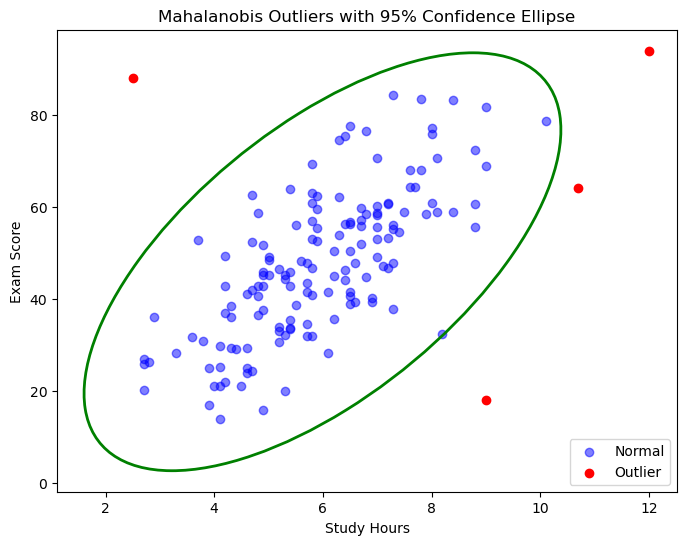

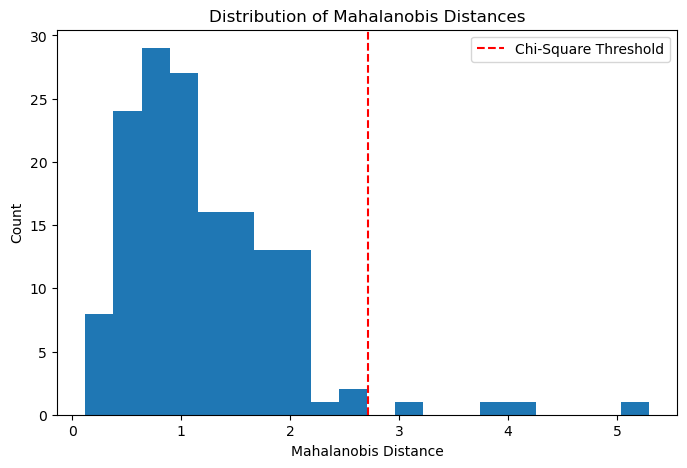

In [22]:
from matplotlib.patches import Ellipse

mask_chi=mahal>chi_thresh
fig,ax=plt.subplots(figsize=(8,6))
ax.scatter(df.loc[~mask_chi,"study_hours"],df.loc[~mask_chi,"exam_score"],alpha=0.5,color="blue",label="Normal")
ax.scatter(df.loc[mask_chi,"study_hours"],df.loc[mask_chi,"exam_score"],color="red",zorder=5,label="Outlier")

vals,vecs=np.linalg.eigh(cov)
order=vals.argsort()[::-1]
vals,vecs=vals[order],vecs[:,order]
angle=np.degrees(np.arctan2(*vecs[:,0][::-1]))
t=np.sqrt(chi2.ppf(0.975,df=2))
ell=Ellipse(mean,2*t*np.sqrt(vals[0]),2*t*np.sqrt(vals[1]),angle=angle,fill=False,edgecolor="green",lw=2)
ax.add_patch(ell)
ax.set_title("Mahalanobis Outliers with 95% Confidence Ellipse")
ax.set_xlabel("Study Hours")
ax.set_ylabel("Exam Score")
ax.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(mahal,bins=20)
plt.axvline(chi_thresh,color="red",linestyle="--",label="Chi-Square Threshold")
plt.title("Distribution of Mahalanobis Distances")
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Count")
plt.legend()
plt.show()

## B.5 Comparing the Two Methods

**B10:** side-by-side scatter plots, Euclidean IQR-flagged vs Mahalanobis chi-square-flagged

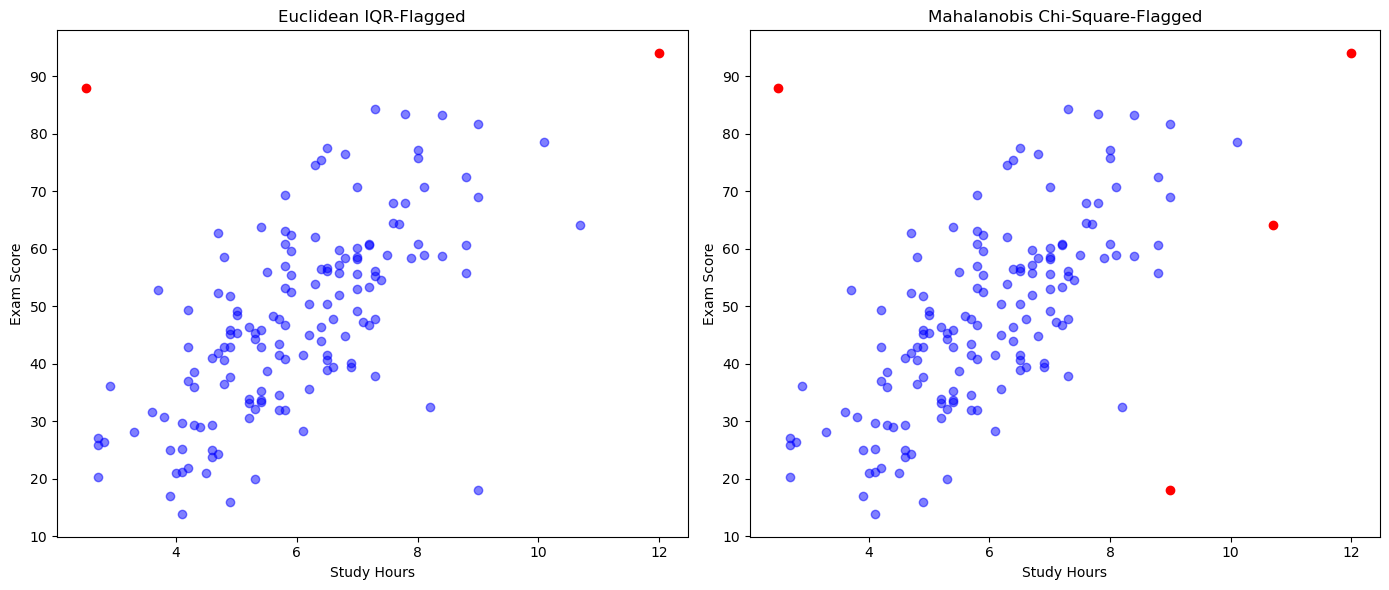

In [23]:
fig,ax=plt.subplots(1,2,figsize=(14,6))
ax[0].scatter(df.loc[~mask_e,"study_hours"],df.loc[~mask_e,"exam_score"],alpha=0.5,color="blue")
ax[0].scatter(df.loc[mask_e,"study_hours"],df.loc[mask_e,"exam_score"],color="red",zorder=5)
ax[0].set_title("Euclidean IQR-Flagged")
ax[0].set_xlabel("Study Hours")
ax[0].set_ylabel("Exam Score")
ax[1].scatter(df.loc[~mask_chi,"study_hours"],df.loc[~mask_chi,"exam_score"],alpha=0.5,color="blue")
ax[1].scatter(df.loc[mask_chi,"study_hours"],df.loc[mask_chi,"exam_score"],color="red",zorder=5)
ax[1].set_title("Mahalanobis Chi-Square-Flagged")
ax[1].set_xlabel("Study Hours")
ax[1].set_ylabel("Exam Score")
plt.tight_layout()
plt.show()

**Answer:** mahalanobis distance accounts for the correlation between the two columns, so it measures distance relative to the diagonal spread of the data cloud rather than treating every direction equally. points b and c don't have extreme values in either column alone, but they fall off the expected positive-correlation line, and mahalanobis stretches the distance metric in that off-diagonal direction, making them look far more unusual. euclidean distance, even after z-scoring, only reacts to how far a point's individual coordinates are from the mean, so it cannot notice that the combination of values is what is wrong - this is why row 152's euclidean distance (2.59, below every threshold) is so much lower than its mahalanobis distance (4.26, clearly flagged).

**B11:** scatter plot with four colour categories - Mahalanobis only, Euclidean only, both, neither

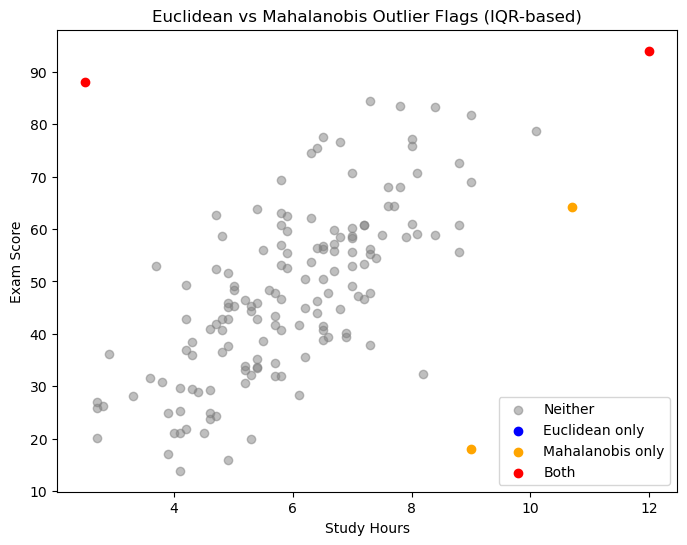

In [24]:
euclid_flag=euclid>iqr_thresh_e
mahal_flag=mahal>iqr_thresh_m

both=euclid_flag&mahal_flag
euclid_only=euclid_flag&(~mahal_flag)
mahal_only=mahal_flag&(~euclid_flag)
neither=(~euclid_flag)&(~mahal_flag)

plt.figure(figsize=(8,6))
plt.scatter(df.loc[neither,"study_hours"],df.loc[neither,"exam_score"],color="gray",alpha=0.5,label="Neither")
plt.scatter(df.loc[euclid_only,"study_hours"],df.loc[euclid_only,"exam_score"],color="blue",label="Euclidean only")
plt.scatter(df.loc[mahal_only,"study_hours"],df.loc[mahal_only,"exam_score"],color="orange",label="Mahalanobis only")
plt.scatter(df.loc[both,"study_hours"],df.loc[both,"exam_score"],color="red",label="Both")
plt.title("Euclidean vs Mahalanobis Outlier Flags (IQR-based)")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.legend()
plt.show()

## B.6 Take-Home

**B12:** add project_score column, recompute Mahalanobis on all three columns with a chi2(df=3) threshold

In [25]:
df["project_score"]=np.clip(0.7*df["exam_score"]+rng.normal(0,8,153),0,100)

X3=df[["study_hours","exam_score","project_score"]].values
mean3=X3.mean(axis=0)
cov3=np.cov(X3.T)
VI3=np.linalg.inv(cov3)
mahal3=np.array([mahalanobis(x,mean3,VI3) for x in X3])

chi_thresh3=np.sqrt(chi2.ppf(0.975,df=3))
flagged3=df.index[mahal3>chi_thresh3]
print("flagged indices with 3 columns:",flagged3.tolist())
print("flagged indices with 2 columns:",chi_idx.tolist())

flagged indices with 3 columns: [87, 150, 151, 152]
flagged indices with 2 columns: [87, 150, 151, 152]


**Answer:** none - the 3-column flagged set (87, 150, 151, 152) is identical to the 2-column flagged set. adding project_score, a noisy but correlated derivative of exam_score, did not surface any new joint-breaking outliers in this run.

**B13:** implement Mahalanobis distance from scratch using only NumPy, verify against scipy with np.allclose

In [26]:
def mahalanobis_manual(x,mean,cov_inv):
    diff=x-mean
    return np.sqrt(diff@cov_inv@diff)

mahal_manual=np.array([mahalanobis_manual(x,mean,VI) for x in X])
print("matches scipy version:",np.allclose(mahal_manual,mahal))

matches scipy version: True
